# Setup

In [2]:
# !pip install -U langchain langchain-community langchain-experimental langchain-core langchain_huggingface langchain-openai langsmith langchainhub pymupdf sentence-transformers faiss-cpu pypdf

## OpenAI Key 등록
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [ ]:
import os

os.environ['OPENAI_API_KEY'] = 'sk-'


# [Reranker](https://python.langchain.com/docs/integrations/retrievers/)
- Reranker(리랭커)는 현대적인 두 단계 검색 시스템(Two-Stage Retrieval System)에서 사용되는 핵심 컴포넌트입니다. 대규모 데이터셋에서 효율적이고 정확한 검색을 수행하기 위해 설계되었으며, 주로 첫 번째 단계인 Retriever가 찾아낸 문서들의 순위를 재조정하는 역할을 합니다.

## [Reranker가 필요한 이유](https://aws.amazon.com/ko/blogs/tech/korean-reranker-rag/)

먼저 현재 RAG의 문제점에 대해서 살펴보도록 하겠습니다. RAG는 수많은 텍스트 문서에서 의미론적 검색 (Semantic search) 과정을 수행합니다. 의미론적 검색에는 일반적으로 벡터 검색을 활용 되는데, 이 과정에서 두 가지 정보 손실이 발생하게 됩니다.
- `첫 번째는 문서의 임베딩 벡터 변환 과정에서의 손실입니다.` 임베딩 벡터 변환이란 문서를 n개의 숫자로 재 표현하는 것을 의미하는데, 정보의 손실은 문서가 긴 경우에 정해진 벡터의 차원으로 표현하기 어려울 때 발생하게 됩니다.
- `두 번째는 검색 과정에서의 손실입니다.` RAG는 검색 시간 단축을 위해 Approximate Nearnest Neighbor search (ANNs) 기술을 활용합니다. 이 방법은 질문과 문서 사이의 관련성 체크 횟수를 현저히 줄임으로써 검색속도를 높일 수 있습니다. 하지만 이 과정에서 발생하는 관련성 정확도 하락이 정보의 손실로 나타나게 됩니다. 이러한 정보 손실로 인해 LLM으로 전달되는 컨텍스트의 상위 k개 이내에서 질문에 대한 관련 정보가 누락되는 경우가 발생합니다.

- 이러한 문제는 검색 후 반환되는 문서수를 늘림 (k 증가) 으로써 간단히 해결할 수 있습니다. 하지만 이 방법은 LLM에 전달하는 컨텍스트가 늘어나기 때문에 비용 효율적이지 않습니다.
- 그 뿐만이 아닙니다. 최근 출판된 논문에 따르면 RAG의 정확도는 관련정보의 컨텍스트 내 존재 유무가 아닌, 순서라는 것을 발견하였습니다.

즉, 관련 정보가 컨텍스트 내 상위권에 위치하고 있을 때 좋은 답변을 얻을 수 있다는 뜻 입니다.

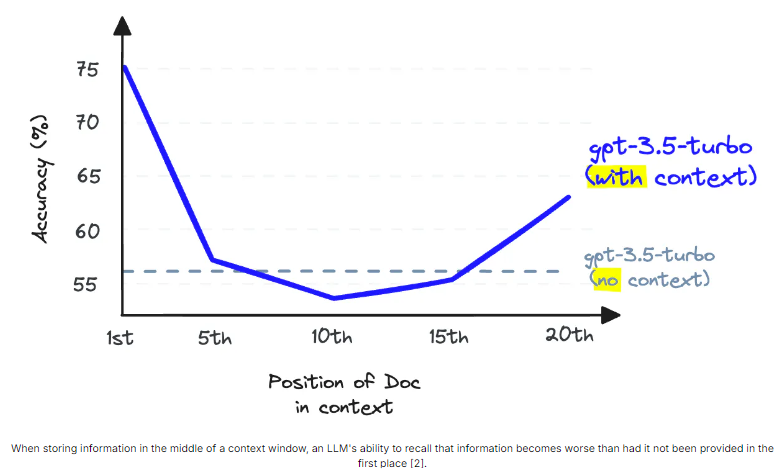

##[Power of Rerankers](https://www.pinecone.io/learn/series/rag/rerankers/)
- 기존에 벡터 검색을 위해 사용하는 구조가 `Bi-encoder`라면, `rerank`를 위한 구조는 `Cross-encoder`입니다.
- `Bi-encoder`는 질의와 정보를 각각 임베딩한 후 유사도를 계산합니다.
- `Cross-encoder`는 질의와 정보를 입력으로 사용하여 유사도를 출력합니다. 질의와 정보를 각각 입력하고 유사도를 얻는 `Bi-encoder`와 다르게 질의와 정보의 내용을 한번에 고려하기 때문에 더욱 정확한 유사도를 얻을 수 있다고 합니다. 이 유사도를 사용하여 질의와의 관련성에 따라 정보(문서)를 재정렬합니다.
- 하지만 `Cross-encoder`는 모든 조합들을 활용해 인풋으로 활용해야 하기 때문에, 비용이 높습니다. 때문에 일반적인 벡터 검색(`retrieval`)을 진행한 후, `reranker` 기반으로 순위를 재정렬하는 경우가 일반적입니다.


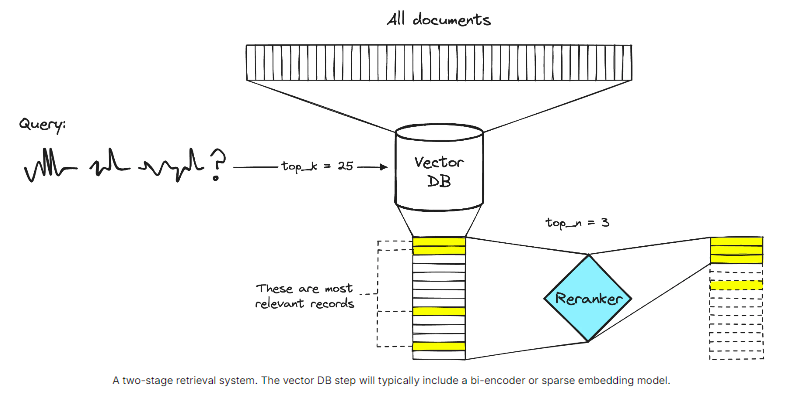

### Bi-encoder

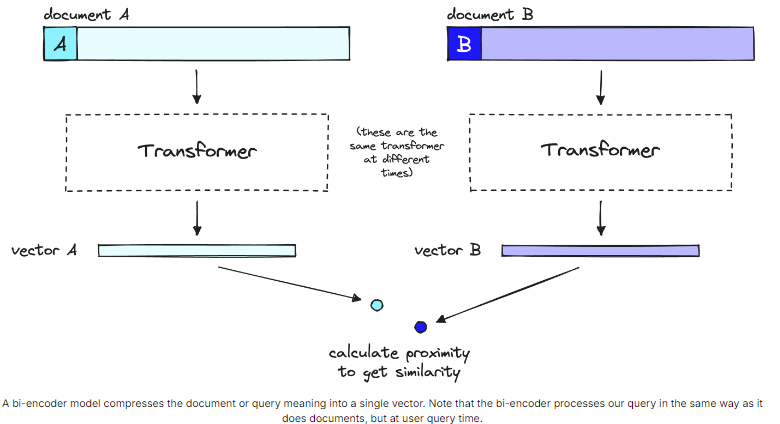

### Cross-encoder

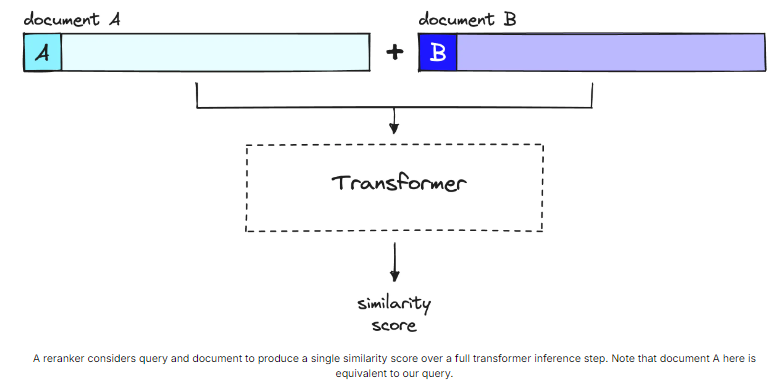

## Reranker 장단점

- 장점
  - 검색 정확도 크게 향상
  - 복잡한 의미적 관계 모델링 가능
  - 첫 단계 검색의 한계 보완
- 단점
  - 계산 비용 증가
  - 처리 시간 증가
  - 대규모 데이터셋에 직접 적용 어려움

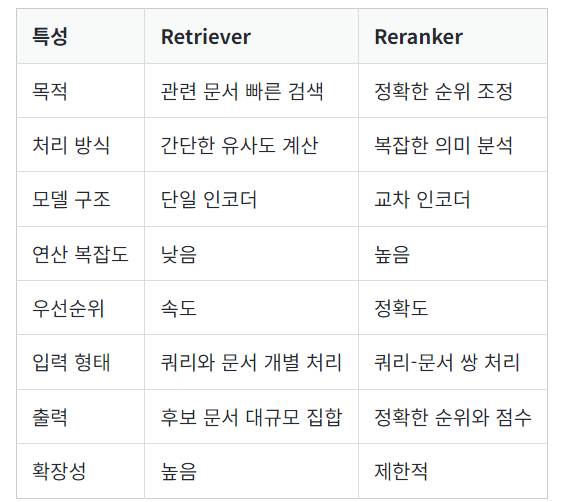

# Reranker 예제
- Cross encoder reranker는 검색 증강 생성(RAG) 시스템의 성능을 향상시키기 위해 사용되는 기술입니다. 이 문서는 Hugging Face의 cross encoder 모델을 사용하여 retriever에서 reranker를 구현하는 방법을 설명합니다.

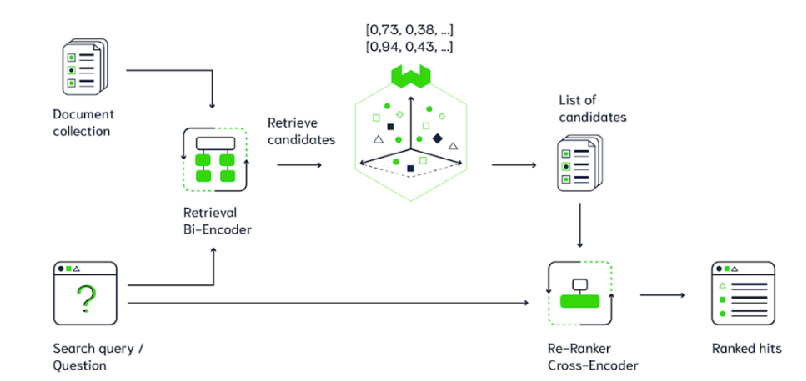

In [1]:
# 문서 출력 도우미 함수
def pretty_print_docs(docs):
    print(
        f"\n{'-' * 100}\n".join(
            [f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]
        )
    )

In [2]:
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Vector DB

- 문서 로드

In [3]:
# 문서 로드
DATA_PATH = "./data/"

documents = TextLoader(DATA_PATH+"rag-keywords.txt").load()

In [4]:
len(documents)

1

- 텍스트 분할기 설정

In [5]:
# 텍스트 분할기 설정
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

- 문서 분할

In [6]:
# 문서 분할
texts = text_splitter.split_documents(documents)

In [7]:
len(texts)

15

- 임베딩 모델 설정

In [8]:
# 임베딩 모델 설정
embeddingsModel = HuggingFaceEmbeddings(
    model_name="sentence-transformers/msmarco-distilbert-dot-v5",
    cache_folder="./models/",
    model_kwargs={"device": "cpu"}  # CPU 사용
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
embeddingsModel

HuggingFaceEmbeddings(model_name='sentence-transformers/msmarco-distilbert-dot-v5', cache_folder='./models/', model_kwargs={'device': 'cpu'}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

- 문서로부터 vectorstore 생성

In [11]:
vector_db = Chroma.from_documents(
    documents=texts, # 문서 리스트
    embedding=embeddingsModel, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("파일이 Chroma VectorStore에 저장되었습니다.")

파일이 Chroma VectorStore에 저장되었습니다.


## [CrossEncoderReranker](https://medium.com/@rhitesh.ksingh99/designing-rag-pipelines-using-langchain-and-evaluating-them-using-ragas-4e7d09262bac)
- 기본 retriever를 `ContextualCompressionRetriever`로 감싸보겠습니다. `CrossEncoderReranker`는 HuggingFaceCrossEncoder를 사용하여 반환된 결과를 재정렬합니다.
- 다국어 지원 BGE Reranker: `bge-reranker-v2-m3`

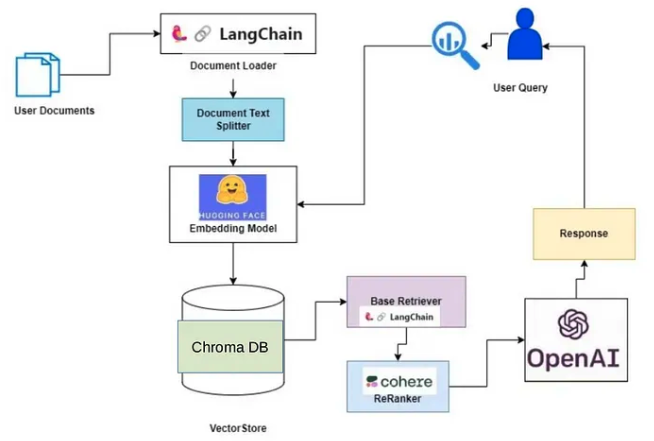

### CrossEncoderReranker

- HuggingFaceCrossEncoder

In [21]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# 모델 초기화
model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3",
                                model_kwargs = {
                                    'device': 'cpu', 'cache_folder': './models/'
                                })

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

- CrossEncoderReranker

In [22]:
from langchain.retrievers.document_compressors import CrossEncoderReranker

# 상위 3개의 문서 선택
compressor = CrossEncoderReranker(model=model, top_n=3)

### ContextualCompressionRetriever

- MultiQueryRetriever

In [26]:
from langchain_openai import ChatOpenAI

# ChatOpenAI 언어 모델을 초기화합니다. temperature는 0으로 설정합니다.
llm = ChatOpenAI(temperature=0, model="gpt-5-nano")

In [27]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=vector_db.as_retriever(), llm=llm
)

- ContextualCompressionRetriever

In [28]:
from langchain.retrievers import ContextualCompressionRetriever

# 문서 압축 검색기 초기화
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=multi_query_retriever
)

### Run
- 압축된 문서 검색

In [29]:
# 질의 설정
query = "Word2Vec 에 대해서 알려줄래?"

# 압축된 문서 검색
compressed_docs = compression_retriever.invoke(query)

In [30]:
len(compressed_docs)

2

- 문서 출력

In [31]:
# 문서 출력
pretty_print_docs(compressed_docs)

Document 1:

Open Source

정의: 오픈 소스는 소스 코드가 공개되어 누구나 자유롭게 사용, 수정, 배포할 수 있는 소프트웨어를 의미합니다. 이는 협업과 혁신을 촉진하는 데 중요한 역할을 합니다.
예시: 리눅스 운영 체제는 대표적인 오픈 소스 프로젝트입니다.
연관키워드: 소프트웨어 개발, 커뮤니티, 기술 협업

Structured Data

정의: 구조화된 데이터는 정해진 형식이나 스키마에 따라 조직된 데이터입니다. 이는 데이터베이스, 스프레드시트 등에서 쉽게 검색하고 분석할 수 있습니다.
예시: 관계형 데이터베이스에 저장된 고객 정보 테이블은 구조화된 데이터의 예입니다.
연관키워드: 데이터베이스, 데이터 분석, 데이터 모델링

Parser
----------------------------------------------------------------------------------------------------
Document 2:

정의: LLM은 대규모의 텍스트 데이터로 훈련된 큰 규모의 언어 모델을 의미합니다. 이러한 모델은 다양한 자연어 이해 및 생성 작업에 사용됩니다.
예시: OpenAI의 GPT 시리즈는 대표적인 대규모 언어 모델입니다.
연관키워드: 자연어 처리, 딥러닝, 텍스트 생성

FAISS (Facebook AI Similarity Search)

정의: FAISS는 페이스북에서 개발한 고속 유사성 검색 라이브러리로, 특히 대규모 벡터 집합에서 유사 벡터를 효과적으로 검색할 수 있도록 설계되었습니다.
예시: 수백만 개의 이미지 벡터 중에서 비슷한 이미지를 빠르게 찾는 데 FAISS가 사용될 수 있습니다.
연관키워드: 벡터 검색, 머신러닝, 데이터베이스 최적화

Open Source


## [CohereRerank](https://python.langchain.com/docs/integrations/retrievers/cohere-reranker/)
- Cohere는 기업이 인간-기계 상호작용을 개선할 수 있도록 돕는 자연어 처리 모델을 제공하는 캐나다의 스타트업입니다.
- Cohere Rerank는 의미론적 콘텐츠, 사용자 의도, 문맥과의 관련성 등 추가 기준에 따라 검색된 문서의 관련성을 재평가하고 순서를 변경하여 유사성 점수를 산출하는 것을 목표로 합니다.
- 그런 다음 이 점수를 사용하여 쿼리의 관련성에 따라 문서를 재정렬합니다. 다음 이미지는 Rerank를 사용한 재정렬 결과를 보여줍니다.

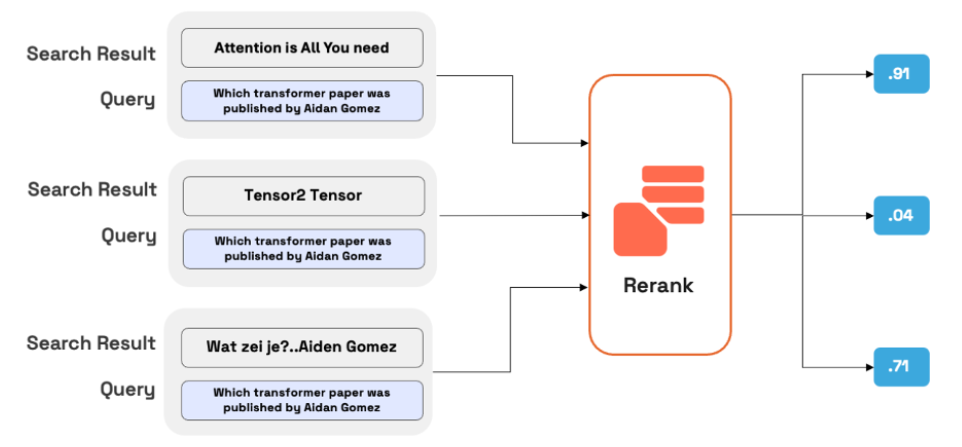

## [JinaRerank](https://python.langchain.com/docs/integrations/document_transformers/jina_rerank/)
- Weaviate Agents는 Weaviate의 벡터 데이터베이스와 LLM을 활용하여 데이터를 저장, 검색 및 변환합니다.
- 이 턴키 방식은 데이터 파이프라인에서 관리해야 할 단계가 줄어든다는 것을 의미합니다.
- 데이터를 쿼리, 변환 또는 개인화하든 에이전트에게 작업을 위임하면 운영 오버헤드를 대폭 줄이고 오류가 발생하기 쉬운 스크립트를 최소화하며 통찰력(또는 사용자 영향)을 더 빨리 얻을 수 있습니다.

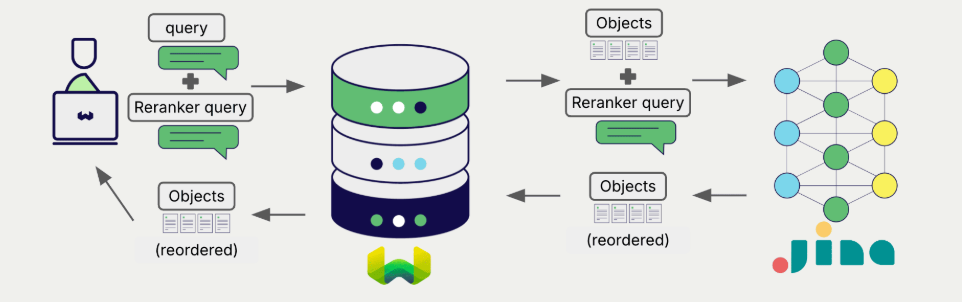